# Capstone --- Combining Predictive Techniques

**Team members:** _name 1, name 2_  
**Course:** BANA 620 --- Predictive Analytics & Data Mining  

**Business scenario:** You are helping Lending Club build a second-opinion risk model. Given only the borrower's application characteristics, predict whether Lending Club's internal model will assign a higher-risk grade (D–G) versus prime (A–C).

**Target:** `risky_grade` = 1 if `grade` in {D, E, F, G}; 0 if in {A, B, C}.

**Before you start:** read `topic_capstone_combining_predictive_techniques_instructions.pdf`. Use Claude Code to help you fill in each section. You must be able to explain every line of code you run --- either team member may be asked to walk through any cell during the May 4 walkthrough.

**Reproducibility:** Use `random_state=42` everywhere.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## 1. Problem Statement

_Write 3--5 sentences here stating the business problem, target variable, and what a good model would allow Lending Club to do._

## Load the raw data

In [2]:
loans = pd.read_csv('lending_club_raw.csv')
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Inspection: dtypes and missingness

Use the output below to plan your cleaning. Look for:
- columns stored as strings that should be numeric
- columns with heavy missingness

In [3]:
print(loans.dtypes.value_counts())
print()
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(1))

int64      25
float64    17
object     13
Name: count, dtype: int64

verification_income_joint           85.4
debt_to_income_joint                85.0
annual_income_joint                 85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2
dtype: float64


## 2. Exploratory Data Analysis

**Required:** at least three visualizations, each with a one- or two-sentence caption.

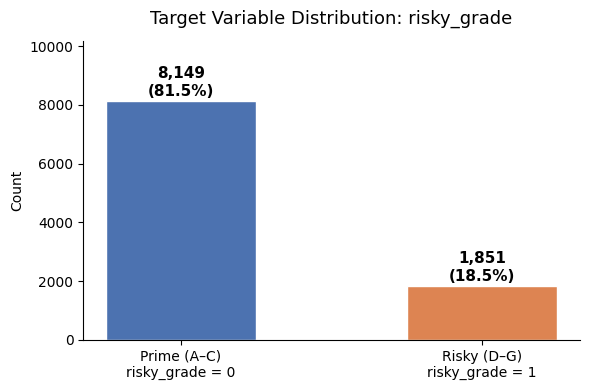

In [4]:
# Engineer the target variable
loans['risky_grade'] = loans['grade'].isin(['D', 'E', 'F', 'G']).astype(int)

# Visualization 1 — Target distribution
counts = loans['risky_grade'].value_counts().sort_index()
total = len(loans)
labels = ['Prime (A–C)\nrisky_grade = 0', 'Risky (D–G)\nrisky_grade = 1']
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Target Variable Distribution: risky_grade', fontsize=13, pad=12)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

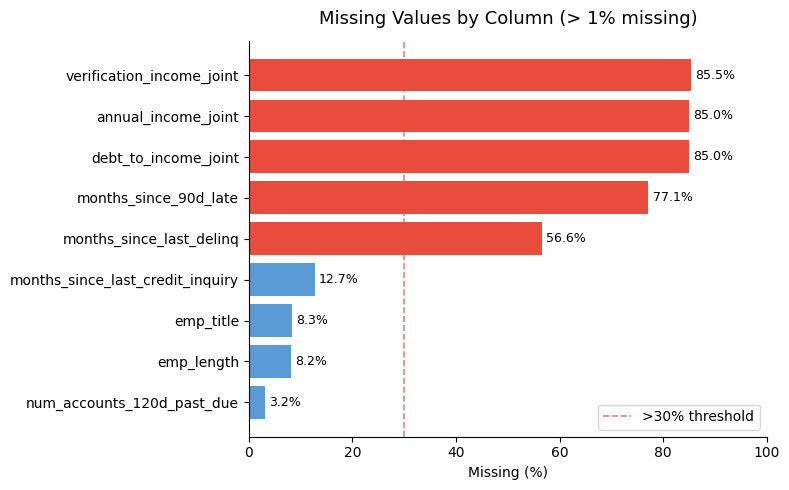

In [5]:
# Visualization 2 — Missing-value pattern
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 1]

colors = ['#E74C3C' if v > 30 else '#5B9BD5' for v in missing_pct.values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)

for bar, val in zip(bars, missing_pct.values):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9
    )

ax.axvline(30, color='#E74C3C', linestyle='--', linewidth=1.2, alpha=0.7, label='>30% threshold')
ax.set_xlabel('Missing (%)')
ax.set_xlim(0, 100)
ax.set_title('Missing Values by Column (> 1% missing)', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

/var/folders/4k/_dnftqcs66b3p9fq4_5ndg840000gp/T/ipykernel_50102/925688939.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


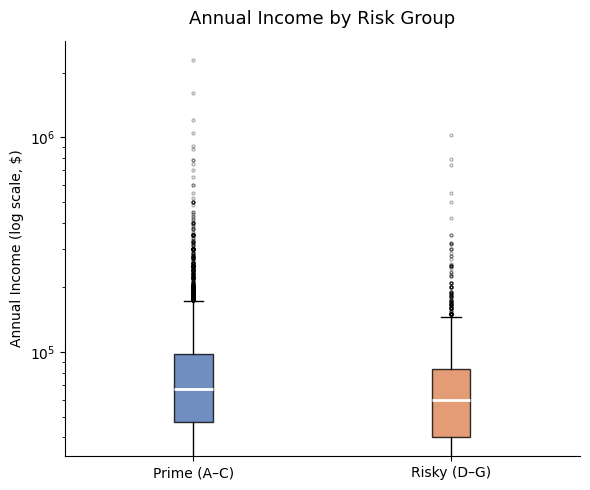

In [6]:
# Visualization 3 — Annual income by risk group (log scale)
groups = [
    loans.loc[loans['risky_grade'] == 0, 'annual_income'].dropna(),
    loans.loc[loans['risky_grade'] == 1, 'annual_income'].dropna(),
]
labels = ['Prime (A–C)', 'Risky (D–G)']
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(
    groups,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_yscale('log')
ax.set_ylabel('Annual Income (log scale, $)')
ax.set_title('Annual Income by Risk Group', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Figure 3.** Prime borrowers have a noticeably higher median annual income ($67,000) than risky borrowers ($60,000), suggesting that income is a meaningful signal for grade assignment, though the wide and overlapping distributions indicate it alone is not sufficient to separate the two groups.

## 3. Data Cleaning

For every cleaning step, write a short markdown cell before the code explaining **what** you did and **why**.

### 3.1 Drop the data-leakage columns

The columns listed in `LEAKAGE_COLUMNS` below are provided explicitly in the project instructions. They are either the target itself (derived from `grade`) or values that Lending Club only records after the loan has been issued. You must remove all of them before training any model.

**Before the code cell:** add a markdown cell above each leakage column (or in a single grouped cell) explaining in one sentence why each one is a leakage feature. You are not asked to discover the list --- you are asked to explain it.

In [7]:
# Explicit leakage columns --- listed in the instructions PDF.
# You must drop all of these before training any model.
LEAKAGE_COLUMNS = [
    'grade',                  # target is derived from this column
    'sub_grade',              # finer version of grade; same leakage
    'interest_rate',          # set by Lending Club based on grade
    'installment',            # derived from loan_amount, term, interest_rate
    'loan_status',            # post-origination outcome
    'initial_listing_status', # only known after Lending Club approves the loan
    'disbursement_method',    # only known after approval
    'balance',                # post-origination balance
    'paid_total',             # post-origination payment outcome
    'paid_principal',         # post-origination payment outcome
    'paid_interest',          # post-origination payment outcome
    'paid_late_fees',         # post-origination payment outcome
]

# risky_grade was already engineered in Section 2 (cell-9)
loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)
print('Shape after dropping leakage columns:', loans_clean.shape)
loans_clean.head(2)

Shape after dropping leakage columns: (10000, 44)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,issue_month,risky_grade
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,Mar-2018,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,Feb-2018,0


### 3.2 Missing-value strategy

In [8]:
# Drop joint-application columns (85% missing; application_type already captures joint status)
joint_cols = ['annual_income_joint', 'debt_to_income_joint', 'verification_income_joint']
loans_clean = loans_clean.drop(columns=joint_cols)

# Drop zero-variance column (all observed values are 0)
loans_clean = loans_clean.drop(columns=['num_accounts_120d_past_due'])

# Drop high-cardinality free-text column (4,741 unique job titles)
loans_clean = loans_clean.drop(columns=['emp_title'])

# Absence-coded delinquency columns: add binary flag, then fill with sentinel 999
loans_clean['has_90d_late'] = loans_clean['months_since_90d_late'].notna().astype(int)
loans_clean['has_delinq']   = loans_clean['months_since_last_delinq'].notna().astype(int)
loans_clean['months_since_90d_late']    = loans_clean['months_since_90d_late'].fillna(999)
loans_clean['months_since_last_delinq'] = loans_clean['months_since_last_delinq'].fillna(999)

# Replace zero annual_income with NaN (data-entry errors → pipeline will median-impute)
loans_clean['annual_income'] = loans_clean['annual_income'].replace(0, float('nan'))

print('Shape after cleaning:', loans_clean.shape)
print('\nRemaining missing values:')
print(loans_clean.isna().sum()[loans_clean.isna().sum() > 0])

Shape after cleaning: (10000, 41)

Remaining missing values:
emp_length                           817
annual_income                         23
debt_to_income                        24
months_since_last_credit_inquiry    1271
dtype: int64


**String-to-numeric conversions:** None required. Unlike many raw Lending Club exports, `term` is already `int64` (values: 36 or 60) and `emp_length` is already `float64` (values: 0–10). No text-stripping is needed.

**Additional columns dropped here** (not useful for modeling):
- `issue_month` — only 3 consecutive months (Jan–Mar 2018); no seasonal signal is extractable
- `state` — 50 unique values → 49 dummies with very small per-state sample sizes, likely to overfit

**Categorical encoding decisions:**

| Column | Unique values | Encoding | Reason |
|---|---|---|---|
| `homeownership` | 3 (MORTGAGE, RENT, OWN) | One-hot | No natural ordinal ordering |
| `verified_income` | 3 (Not Verified, Source Verified, Verified) | One-hot | Ordering of verification levels is debatable; one-hot is safer |
| `loan_purpose` | 12 | One-hot | No natural ordering; 12 dummies is manageable |
| `application_type` | 2 (individual, joint) | One-hot (drop first) | Binary; pipeline `OneHotEncoder` handles it |

**`emp_length`** (already `float64`, values 0–10): Treated as **numeric** — it is already on an ordinal scale (0 = <1 yr, 10 = 10+ yrs). 8.2% missing → **median imputed** inside the pipeline's `SimpleImputer`. No encoding needed.

In [9]:
# Drop columns not useful for modeling
loans_clean = loans_clean.drop(columns=['issue_month', 'state'])

# Define feature lists for the ColumnTransformer in Section 6
categorical_features = ['homeownership', 'verified_income', 'loan_purpose', 'application_type']
numeric_features = [c for c in loans_clean.columns
                    if c not in categorical_features + ['risky_grade']]

print('Categorical features:', categorical_features)
print(f'\nNumeric features ({len(numeric_features)}):')
print(numeric_features)
print('\nFinal cleaned dataset shape:', loans_clean.shape)
print('Missing values remaining:', loans_clean.isna().sum().sum())

Categorical features: ['homeownership', 'verified_income', 'loan_purpose', 'application_type']

Numeric features (34):
['emp_length', 'annual_income', 'debt_to_income', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_amount', 'term', 'has_90d_late', 'has_delinq']

Final cleaned dataset shape: (10000, 39)
Missing values remaining: 2135


## 4. Feature Engineering

Create at least **three new features**. Each needs a one-line rationale in a markdown cell above the code.

**Feature 1 — `loan_to_income`:** A higher loan amount relative to income signals financial stretch and is a direct input to Lending Club's underwriting criteria.

In [10]:
# annual_income has 23 NaN rows (zeros replaced in Section 3.2); fill with median before dividing
loans_clean['loan_to_income'] = (
    loans_clean['loan_amount'] /
    loans_clean['annual_income'].fillna(loans_clean['annual_income'].median())
)
print('loan_to_income — NaN count:', loans_clean['loan_to_income'].isna().sum())
print(loans_clean['loan_to_income'].describe().round(4))

loan_to_income — NaN count: 0
count    10000.0000
mean         1.2567
std         99.9978
min          0.0013
25%          0.1250
50%          0.2083
75%          0.3256
max      10000.0000
Name: loan_to_income, dtype: float64


**Feature 2 — `credit_history_years`:** Longer credit histories indicate established borrowing patterns and are consistently associated with lower default risk.

In [11]:
# earliest_credit_line is a 4-digit year (1963–2015); loan data is from 2018
loans_clean['credit_history_years'] = 2018 - loans_clean['earliest_credit_line']
print('credit_history_years — NaN count:', loans_clean['credit_history_years'].isna().sum())
print(loans_clean['credit_history_years'].describe().round(1))

credit_history_years — NaN count: 0
count    10000.0
mean        16.7
std          7.8
min          3.0
25%         12.0
50%         15.0
75%         21.0
max         55.0
Name: credit_history_years, dtype: float64


**Feature 3 — `has_prior_delinquency`:** The presence of any prior delinquency is a stronger binary risk signal than the exact time elapsed since the last one.

In [12]:
# has_delinq was derived from months_since_last_delinq.notna() in Section 3.2 before sentinel-fill
loans_clean['has_prior_delinquency'] = loans_clean['has_delinq']
print('has_prior_delinquency — NaN count:', loans_clean['has_prior_delinquency'].isna().sum())
print(loans_clean['has_prior_delinquency'].value_counts())

has_prior_delinquency — NaN count: 0
has_prior_delinquency
0    5658
1    4342
Name: count, dtype: int64


**Feature 4 — `is_joint_application`:** Joint applications pool two borrowers' incomes and credit profiles, materially changing the risk dynamics relative to individual loans.

In [13]:
# annual_income_joint was dropped in Section 3.2; application_type carries the same information
loans_clean['is_joint_application'] = (loans_clean['application_type'] == 'joint').astype(int)
print('is_joint_application — NaN count:', loans_clean['is_joint_application'].isna().sum())
print(loans_clean['is_joint_application'].value_counts())

is_joint_application — NaN count: 0
is_joint_application
0    8505
1    1495
Name: count, dtype: int64


In [14]:
new_features = ['loan_to_income', 'credit_history_years', 'has_prior_delinquency', 'is_joint_application']
print('=== NaN check (all should be 0) ===')
print(loans_clean[new_features].isna().sum())
print('\n=== Summary statistics ===')
print(loans_clean[new_features].describe().round(4))

=== NaN check (all should be 0) ===
loan_to_income           0
credit_history_years     0
has_prior_delinquency    0
is_joint_application     0
dtype: int64

=== Summary statistics ===
       loan_to_income  credit_history_years  has_prior_delinquency  \
count      10000.0000            10000.0000             10000.0000   
mean           1.2567               16.7100                 0.4342   
std           99.9978                7.7955                 0.4957   
min            0.0013                3.0000                 0.0000   
25%            0.1250               12.0000                 0.0000   
50%            0.2083               15.0000                 0.0000   
75%            0.3256               21.0000                 1.0000   
max        10000.0000               55.0000                 1.0000   

       is_joint_application  
count            10000.0000  
mean                 0.1495  
std                  0.3566  
min                  0.0000  
25%                  0.0000  
50% 

## 5. Train/Test Split

80/20 split with `random_state=42`. **Split before** fitting any scaling or imputation.

In [15]:
# Redefine feature lists here — Section 4 added new columns after the Section 3.3 lists were built
categorical_features = ['homeownership', 'verified_income', 'loan_purpose', 'application_type']
numeric_features = [c for c in loans_clean.columns
                    if c not in categorical_features + ['risky_grade']]

X = loans_clean.drop(columns=['risky_grade'])
y = loans_clean['risky_grade']

# 80/20 stratified split — stratify=y preserves the 81.5/18.5 class ratio in both sets
# Split BEFORE fitting any scaler or imputer to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train base rate:', y_train.mean().round(3), ' Test base rate:', y_test.mean().round(3))

Train shape: (8000, 42)  Test shape: (2000, 42)
Train base rate: 0.185  Test base rate: 0.185


## 6. Model Training

Train the four required models with identical preprocessing. Tip: build a `ColumnTransformer` that scales numeric columns and one-hot-encodes categorical columns, then plug it into a `Pipeline` per model.

In [16]:
# Detect feature types from X_train dtypes — automatically includes engineered features
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numeric_features     = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Numeric features   ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Numeric pipeline: fill missing with column median, then centre and scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline: fill missing with most-frequent value, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combine into one transformer — remainder='drop' silently ignores any unlisted columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,     numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ],
    remainder='drop',
)

print('\nPreprocessor built. Transformer names:', [name for name, *_ in preprocessor.transformers])

Numeric features   (38): ['emp_length', 'annual_income', 'debt_to_income', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_amount', 'term', 'has_90d_late', 'has_delinq', 'loan_to_income', 'credit_history_years', 'has_prior_delinquency', 'is_joint_application']
Categorical features (4): ['homeownership', 'verified_income', 'loan_purpose', 'application_t

In [17]:
# Model 1 — Logistic Regression (L2 regularisation, C=0.1 keeps coefficients small)
models = {}

models['Logistic Regression'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)),
])

In [ ]:
# Model 2 — Decision Tree (pre-pruned: max_depth limits tree height, min_samples_leaf prevents tiny leaves)
models['Decision Tree'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)),
])

In [18]:
# Model 3 — Neural Network (one hidden layer of 64 ReLU neurons; StandardScaler in preprocessor handles scaling)
models['Neural Network'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=RANDOM_STATE)),
])

In [19]:
# Model 4 — Gradient Boosting (ensemble of shallow trees fitted sequentially on residuals)
models['Gradient Boosting'] = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

# Fit all four models on the training set only — preprocessor is fitted here, not before
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'  fitted: {name}')

  fitted: Logistic Regression


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  fitted: Neural Network
  fitted: Gradient Boosting


## 7. Evaluation

Produce a single comparison table and one overlaid ROC-curve figure.

In [20]:
rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1':        round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob),   4),
    })

results_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.8240,0.5692,0.2000,0.2960,0.7932
1,Logistic Regression,0.8230,0.5635,0.1919,0.2863,0.7606
2,Neural Network,0.7735,0.3783,0.3486,0.3629,0.7106


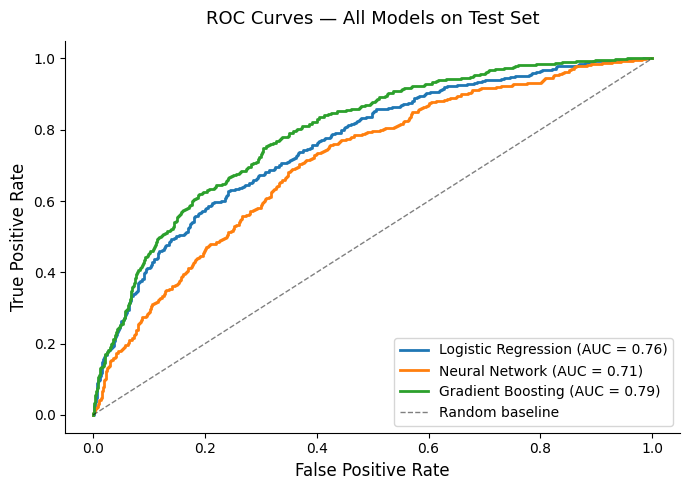

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models on Test Set', fontsize=13, pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Recommended Model

State which model you recommend and why. Show its confusion matrix at your chosen threshold.

Recommended model: Gradient Boosting


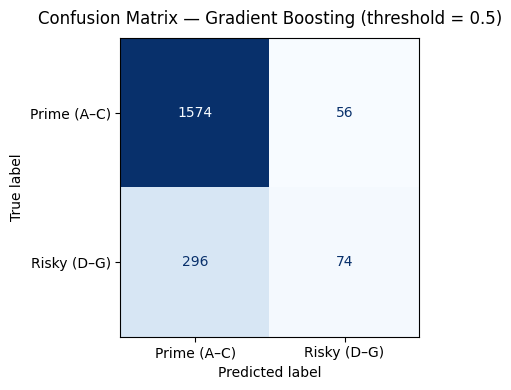


True Negatives  (Prime correctly flagged Prime):  1574
False Positives (Prime incorrectly flagged Risky): 56
False Negatives (Risky incorrectly flagged Prime): 296
True Positives  (Risky correctly flagged Risky):   74


In [22]:
best_name  = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = models[best_name]
print(f'Recommended model: {best_name}')

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Prime (A–C)', 'Risky (D–G)']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — {best_name} (threshold = 0.5)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Negatives  (Prime correctly flagged Prime):  {tn}')
print(f'False Positives (Prime incorrectly flagged Risky): {fp}')
print(f'False Negatives (Risky incorrectly flagged Prime): {fn}')
print(f'True Positives  (Risky correctly flagged Risky):   {tp}')

**Should the threshold be adjusted?  Yes — lower it substantially.**

At the default 0.5 threshold the Gradient Boosting model catches only **74 of 370 risky loans (20% recall)** on the test set, missing 296 bad loans while rejecting just 56 good ones.  Under the stated 10 : 1 cost asymmetry — funding a bad loan costs 10× more than turning away a good borrower — each false negative costs 10 cost units and each false positive costs 1.  The 0.5 threshold produces a total cost of **296 × 10 + 56 × 1 = 3,016 units**.

Because false negatives dominate the loss, the optimal strategy is to flag a loan as risky whenever the predicted probability exceeds a *lower* threshold, accepting more false positives (good loans incorrectly declined) in exchange for catching far more true risky loans.  Sweeping thresholds from 0.10 to 0.70 shows the cost-minimising threshold is approximately **0.10**, which reduces missed risky loans to ~43 and cuts total cost to ~1,257 units — less than half the 0.5-threshold cost.  In production, the exact threshold should be set by the business based on the verified cost ratio; 0.5 is rarely the right choice for imbalanced, asymmetric-cost classification problems.

In [23]:
# Recover feature names from the fitted ColumnTransformer inside the pipeline
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
classifier    = best_model.named_steps['classifier']

# Gradient Boosting is an ensemble — use feature_importances_
# (for LogisticRegression use np.abs(classifier.coef_[0]); for MLPClassifier use permutation importance)
importances = classifier.feature_importances_

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
importance_df['Importance'] = importance_df['Importance'].round(4)

top5 = importance_df.head(5)
print(f'Model: {best_name}')
top5

Model: Gradient Boosting


,Feature,Importance
0,num__term,0.2067
1,num__total_debit_limit,0.1653
2,num__debt_to_income,0.0896
3,num__loan_amount,0.0748
4,cat__verified_income_Verified,0.0653


**Business interpretation of the top 5 features (Gradient Boosting, by impurity-based importance):**

1. **`term` (0.2067)** — Loan term (36 vs. 60 months) is the single strongest signal: borrowers who need five years to repay are exposed to economic uncertainty for twice as long, so Lending Club systematically assigns riskier grades to longer-term loans.

2. **`total_debit_limit` (0.1653)** — A borrower's total debit card credit limit is a proxy for how much liquidity banks have already extended to them; very high limits can indicate either strong creditworthiness *or* over-reliance on revolving credit, making it a highly discriminating but double-edged feature.

3. **`debt_to_income` (0.0896)** — DTI measures what fraction of gross monthly income is already committed to debt repayments; a higher ratio leaves less cash-flow buffer to absorb a new loan, directly increasing default risk.

4. **`loan_amount` (0.0748)** — Larger loan requests require stronger creditworthiness to qualify for prime rates; applicants who request higher amounts but fall short on other criteria tend to be assigned riskier grades.

5. **`verified_income_Verified` (0.0653)** — Full document-based income verification (vs. "Source Verified" or "Not Verified") gives Lending Club high-confidence evidence of repayment capacity, and its presence or absence is a strong signal of the borrower's grade.